### Импорты

Идея - удалить редкие книги и редких пользователей

In [ ]:
!pip install -q surprise

In [ ]:
!pip install -q faiss-gpu

In [ ]:
import faiss

In [ ]:
from surprise import Dataset, Reader, KNNBasic, KNNWithMeans, KNNWithZScore, SVD, SVDpp, NMF, CoClustering
from surprise.model_selection import cross_validate, GridSearchCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from IPython.display import clear_output

from sentence_transformers import SentenceTransformer

import os
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

os.chdir('/content/drive/My Drive/4 курс/Прикладные задачи машинного обучения/Проект "Книги"')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Обработка и анализ датасета

In [ ]:
os.chdir('data')

for zip_file in os.listdir('./'):

    try:
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall()
    except zipfile.BadZipFile:
        continue

    print(f'{zip_file} is unzipped')

Books.csv.zip is unzipped
Ratings.csv.zip is unzipped
Users.csv.zip is unzipped


#### Датасет books

In [ ]:
books = pd.read_csv('Books.csv')

print(f'Строк в датасете {len(books):,}')

Строк в датасете 271,360


<ipython-input-85-98afbca8b933>:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('Books.csv')


Датасет books содержит информацию о книгах и включает следующие столбцы:
* ISBN - международный стандартный книжный номер (уникален для каждой книги, в рамках проекта используется в качестве id книги)
* Book-Title - название книги
* Year-Of-Publication - год выпуска книги
* Publisher - имя издателя книги
* Image-URL-S - ссылка на изображение книги (маленькое)
* Image-URL-M - ссылка на изображение книги (среднее)
* Image-URL-L - ссылка на изображение книги (большое)

В столбце Year-Of-Publication замечены проблемы с определением типа данных, необходимо будет дополнительно обработать этот столбец.

In [ ]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


Удалим ненужные для нашей задачи столбцы, содержащие ссылки на изображения книг.

In [ ]:
books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], inplace=True)

In [ ]:
books['Year-Of-Publication'].unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984, 0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, '2000', '1995', '1999', '2004',
       '2003', '1990', '1994', '1986', '1989', '2002', '1981', '1993',
       '1983', '1982', '1976', '1991', '1977', '1998', '1992', '1996',
       '0', '1997', '2001', '1974', '1968', '1987', '1984', '1988',
       '1963', '1956', '1970', '1985', '1978', '1973', '1980'

Столбец Year-Of-Publication содержит год публикации книги как в виде числа, так и в виде строки.

Помимо этого, замечаем неккоректные значения, такие как имя издателя, значения 0 и год публикации больше текущего.

Удалим записи, содержащие некорректные значения, а для остальных преобразуем строки в числа.

In [ ]:
mask = ~books['Year-Of-Publication'].isin(['0', 0, 'DK Publishing Inc', 'Gallimard'])

books = books[mask]

In [ ]:
books['Year-Of-Publication'] = books['Year-Of-Publication'].astype(int)

In [ ]:
books = books[books['Year-Of-Publication'] <= 2024]

In [ ]:
print(sorted(books['Year-Of-Publication'].unique()))

[1376, 1378, 1806, 1897, 1900, 1901, 1902, 1904, 1906, 1908, 1909, 1910, 1911, 1914, 1917, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2008, 2010, 2011, 2012, 2020, 2021, 2024]


In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266727 entries, 0 to 271359
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 266727 non-null  object
 1   Book-Title           266727 non-null  object
 2   Book-Author          266725 non-null  object
 3   Year-Of-Publication  266727 non-null  int64 
 4   Publisher            266725 non-null  object
dtypes: int64(1), object(4)
memory usage: 12.2+ MB


Теперь столбец Year-Of-Publication содержит корректный тип данных, остальные столбцы должны содержать строковый тип данных и не требуют обработки.

Замечаем, что датасет содержит 4 записи с пустыми значениями в столбцах Book-Author и Publisher, из-за их мизерного количества, просто удалим эти записи не изучая их содержимое.

In [ ]:
books.dropna(inplace=True)

In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266723 entries, 0 to 271359
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 266723 non-null  object
 1   Book-Title           266723 non-null  object
 2   Book-Author          266723 non-null  object
 3   Year-Of-Publication  266723 non-null  int64 
 4   Publisher            266723 non-null  object
dtypes: int64(1), object(4)
memory usage: 12.2+ MB


Изучим распределение книг по дате публикации, для удобного восприятия сгруппируем книги, разбив года публикации на интервалы по сто лет.

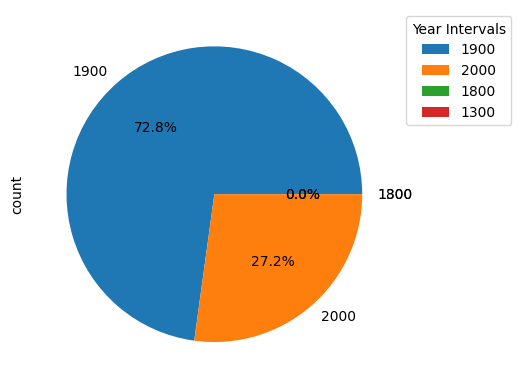

In [ ]:
records_by_year_of_publication = (books['Year-Of-Publication'] // 100) * 100

ax = records_by_year_of_publication.value_counts().plot.pie(autopct='%1.1f%%')

ax.legend(title='Year Intervals', bbox_to_anchor=(1, 1))

Наблюдаем, что большая часть книг в датасете были опубликованы в 20 веке, также датасет содержит мизерное количество книг, выпущенных в 19 и даже 14 веках.

In [ ]:
books[books['Year-Of-Publication'] < 1900]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
171817,0781228956,"Complete Works 10 Volumes [2,6,7,8,9] (Notable...",Benjamin Franklin,1806,Reprint Services Corp
227531,9643112136,Dalan-i bihisht (Dastan-i Irani),Nazi Safavi,1378,Intisharat-i Quqnus
245607,0781268001,"Hugh Wynne, Free Quaker (2 Volumes (BCL1-PS Am...",Silas Weir Mitchell,1897,Reprint Services Corp
253750,964442011X,Tasht-i khun,IsmaÂ°il Fasih,1376,Nashr-i Alburz


Проверив записи о книгах, выпущенных раньше 20 века, оказалось, что только работа Бенжамина Франклина реально была выпущена в 19 веке, остальные записи заполненны некорректно, поэтому удалим их.

In [ ]:
mask = (books['Year-Of-Publication'] < 1900) & (books['ISBN'] != '0781228956')

books = books[~mask]

In [ ]:
books[books['Year-Of-Publication'] < 1900]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
171817,0781228956,"Complete Works 10 Volumes [2,6,7,8,9] (Notable...",Benjamin Franklin,1806,Reprint Services Corp


Теперь датасет можно считать очищеным, в результате обработки он содержит следующее количество строк (было удалено примерно 5k строк).

In [ ]:
print(f'Строк в датасете {len(books):,}')

Строк в датасете 266,720


#### Датасет Users

In [ ]:
users = pd.read_csv('Users.csv')

print(f'Строк в датасете {len(users):,}')

Строк в датасете 278,858


In [ ]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


Датасет users содержит информацию о пользователях и включает следующие столбцы:
* User-ID - id пользователя
* Location - месторасположение пользователя в формате (город, штат/округ/регион, страна)
* Age - возраст пользователя

In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


Большая часть записей датасета не содержит информации о возрасте пользователя. Так-как данная информация может быть полезной для рекомендательной системы, удалим эти записи.

Также, конвертируем тип данных столбца Age из float в целочисленный для удобства восприятия.

In [ ]:
users.dropna(inplace=True)

In [ ]:
users['Age'] = users['Age'].astype(int)

In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
Index: 168096 entries, 1 to 278854
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   User-ID   168096 non-null  int64 
 1   Location  168096 non-null  object
 2   Age       168096 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.1+ MB


In [ ]:
users['Age'].unique()

array([ 18,  17,  61,  26,  14,  25,  19,  46,  55,  32,  24,  20,  34,
        23,  51,  31,  21,  44,  30,  57,  43,  37,  41,  54,  42,  50,
        39,  53,  47,  36,  28,  35,  13,  58,  49,  38,  45,  62,  63,
        27,  33,  29,  66,  40,  15,  60,   0,  79,  22,  16,  65,  59,
        48,  72,  56,  67,   1,  80,  52,  69,  71,  73,  78,   9,  64,
       103, 104,  12,  74,  75, 231,   3,  76,  83,  68, 119,  11,  77,
         2,  70,  93,   8,   7,   4,  81, 114, 230, 239,  10,   5, 148,
       151,   6, 101, 201,  96,  84,  82,  90, 123, 244, 133,  91, 128,
        94,  85, 141, 110,  97, 219,  86, 124,  92, 175, 172, 209, 212,
       237,  87, 162, 100, 156, 136,  95,  89, 106,  99, 108, 210,  88,
       199, 147, 168, 132, 159, 186, 152, 102, 116, 200, 115, 226, 137,
       207, 229, 138, 109, 105, 228, 183, 204,  98, 223, 113, 208, 107,
       157, 111, 146, 118, 220, 143, 140, 189, 127])

Наблюдаем, что датасет содержит информацию о пользователях со странных возрастом, удалим все записи о пользователях, чей возраст больше 100, меньше 13 или равен 0.

In [ ]:
users = users[(users['Age'] <= 100) & (users['Age'] >= 13) & (users['Age'] != 0)]

In [ ]:
users['Age'].unique()

array([ 18,  17,  61,  26,  14,  25,  19,  46,  55,  32,  24,  20,  34,
        23,  51,  31,  21,  44,  30,  57,  43,  37,  41,  54,  42,  50,
        39,  53,  47,  36,  28,  35,  13,  58,  49,  38,  45,  62,  63,
        27,  33,  29,  66,  40,  15,  60,  79,  22,  16,  65,  59,  48,
        72,  56,  67,  80,  52,  69,  71,  73,  78,  64,  74,  75,  76,
        83,  68,  77,  70,  93,  81,  96,  84,  82,  90,  91,  94,  85,
        97,  86,  92,  87, 100,  95,  89,  99,  88,  98])

Изучим распределение возраста пользователей, для удобства восприятия сгруппируем пользователей, разделив на интервалы по 10 лет.

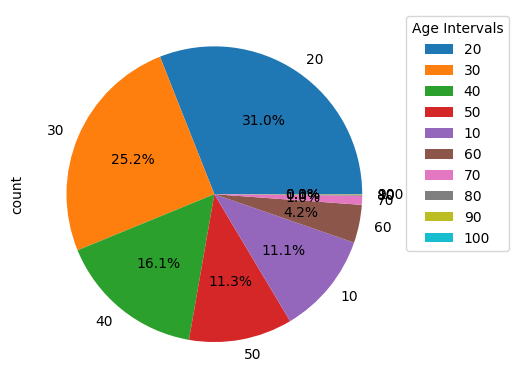

In [ ]:
users_by_age = (users['Age'] // 10) * 10

ax = users_by_age.value_counts().plot.pie(autopct='%1.1f%%')

ax.legend(title='Age Intervals', bbox_to_anchor=(1, 1))

Распределение выглядит вполне реалистичным.

Теперь датасет можно считать очищеным, в результате обработки он содержит следующее количество строк (было удалено примерно 100k строк).

In [ ]:
print(f'Строк в датасете {len(users):,}')

Строк в датасете 166,264


#### Датасет Ratings

In [ ]:
ratings = pd.read_csv('Ratings.csv')

print(f'Строк в датасете {len(ratings):,}')

Строк в датасете 1,149,780


Датасет содержит информацию об оценках пользователей, выставленных для конкретной книги и содержит следующие столбцы:
* User-ID - id пользователя
* ISBN - международный стандартный книжный номер
* Book-Rating - рейтинг, выставленный пользователем

In [ ]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


Датасет не содержит пустых значений.

Изучим распределение оценок пользователей.

<Axes: ylabel='count'>

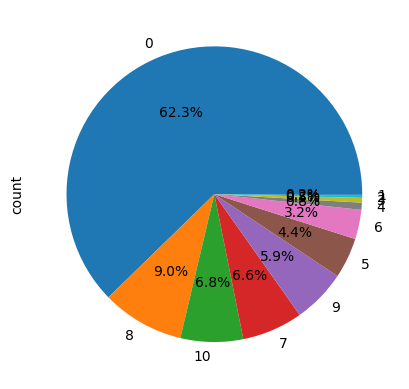

In [ ]:
ratings['Book-Rating'].value_counts().plot.pie(autopct='%1.1f%%')

Абсолютное большинство значений рейтинга в датасете равняется 0, эти записи свидетельствуют о том, что пользователь не выставлял оценку для данной книги.

Удалим такие записи, так-как они не предоставляют нам полезной информации.

In [ ]:
ratings = ratings[ratings['Book-Rating'] != 0]

<Axes: ylabel='count'>

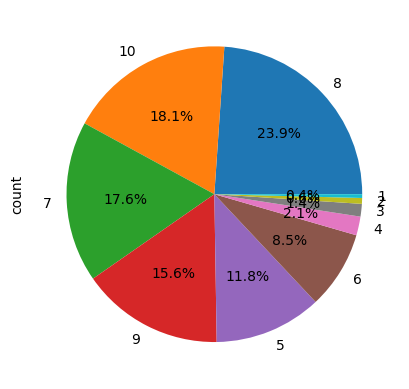

In [ ]:
ratings['Book-Rating'].value_counts().plot.pie(autopct='%1.1f%%')

Новое распределение оценок, в целом, довольно равномерное, за исключением низких рейтингов, что, вполне отражает реальное положение дел, так-как люди не так часто ставят крайне низкие рейтинги для чего бы то ни было.

Теперь датасет можно считать очищеным, в результате обработки он содержит следующее количество строк (было удалено примерно 700k строк).

In [ ]:
print(f'Строк в датасете {len(ratings):,}')

Строк в датасете 433,671


При построении матрицы корреляции книг для создания рекомендательной системы было обнаружено, что такое количество рейтингов переполняет оперативную память.

По этой причине было принято решение использовать часть датасета рейтингов перед объединением датасетов.

In [ ]:
ratings = ratings.sample(n=50000, random_state=37)

In [ ]:
print(f'Строк в датасете {len(ratings):,}')

Строк в датасете 50,000


#### Объединение датасетов

Так-как мы очищали каждый из датасетов отдельно, может оказаться, что у нас, например, есть книги в датасете books, о которых нет информации в датасете ratings.

Чтобы избежать такой ситуации, очистим датасеты books и users от записей, которые не упомянаются в датасете ratings.

In [ ]:
users_mask = ratings['User-ID'].isin(users['User-ID'])

books_mask = ratings['ISBN'].isin(books['ISBN'])

ratings = ratings[users_mask & books_mask].reset_index(drop=True)

In [ ]:
print(f'Строк в датасете {len(ratings):,}')

Строк в датасете 30,372


In [ ]:
mask = books['ISBN'].isin(ratings['ISBN'])

books = books[mask].reset_index(drop=True)

In [ ]:
print(f'Строк в датасете {len(books):,}')

Строк в датасете 22,340


In [ ]:
mask = users['User-ID'].isin(ratings['User-ID'])

users = users[mask].reset_index(drop=True)

In [ ]:
print(f'Строк в датасете {len(users):,}')

Строк в датасете 11,599


Проверим, сохранились ли распределения ключевых показателей каждого из датасетов.

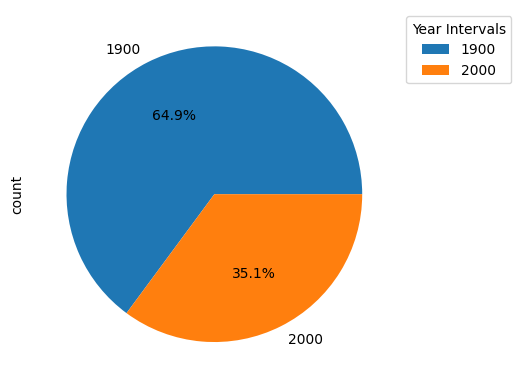

In [ ]:
records_by_year_of_publication = (books['Year-Of-Publication'] // 100) * 100

ax = records_by_year_of_publication.value_counts().plot.pie(autopct='%1.1f%%')

ax.legend(title='Year Intervals', bbox_to_anchor=(1, 1))

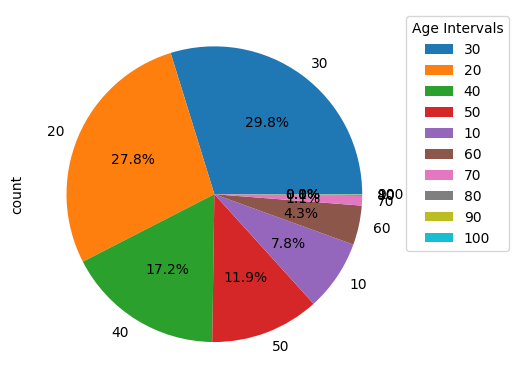

In [ ]:
users_by_age = (users['Age'] // 10) * 10

ax = users_by_age.value_counts().plot.pie(autopct='%1.1f%%')

ax.legend(title='Age Intervals', bbox_to_anchor=(1, 1))

<Axes: ylabel='count'>

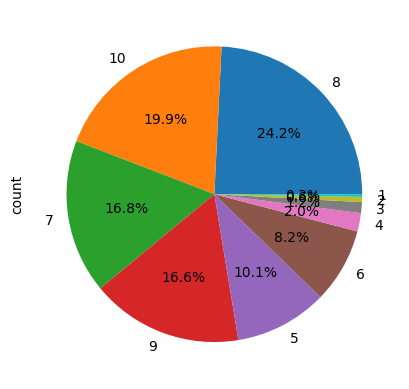

In [ ]:
ratings['Book-Rating'].value_counts().plot.pie(autopct='%1.1f%%')

Показатели незначитильно изменились, можно приступать к созданию рекомендательной системы.

### Создание рекомендательной системы

In [ ]:
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, shuffle=True, random_state=37)

In [ ]:
reader = Reader(rating_scale=(1, 10))

train_data = Dataset.load_from_df(train_ratings, reader)
test_data = Dataset.load_from_df(test_ratings, reader)

#### Алгоритм KNN (user-based фильтрация и item-based фильтрация)

##### KNNBasic

In [ ]:
params = {
    'k': [2, 4, 6, 8, 10],
    'min_k': [1, 2, 3, 4, 5],
}

grid_search = GridSearchCV(KNNBasic, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [ ]:
print(grid_search.best_params['mae'])

{'k': 2, 'min_k': 2}


In [ ]:
cross_validate(KNNBasic(k=2, min_k=2, sim_options={'user_based': True}), test_data, measures=['mae'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     1.4574  1.4452  1.4168  1.4276  1.4900  1.4474  0.0255  
Fit time          0.21    0.26    0.24    0.23    0.24    0.24    0.02    
Test time         0.02    0.02    0.02    0.02    0.02    0.02    0.00    


{'test_mae': array([1.45737337, 1.44519077, 1.41678098, 1.42755932, 1.49004894]),
 'fit_time': (0.20528697967529297,
  0.25989675521850586,
  0.24391627311706543,
  0.2315211296081543,
  0.23517942428588867),
 'test_time': (0.015169382095336914,
  0.01858663558959961,
  0.01828765869140625,
  0.01852583885192871,
  0.015726327896118164)}

In [ ]:
cross_validate(KNNBasic(k=2, min_k=2, sim_options={'user_based': False}), test_data, measures=['mae'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     1.4736  1.4713  1.4227  1.4294  1.4398  1.4474  0.0212  
Fit time          0.45    0.46    0.38    0.37    0.35    0.40    0.04    
Test time         0.02    0.01    0.01    0.01    0.04    0.02    0.01    


{'test_mae': array([1.47360768, 1.47131636, 1.42266762, 1.42943657, 1.43977967]),
 'fit_time': (0.4530520439147949,
  0.4551248550415039,
  0.37906455993652344,
  0.3732912540435791,
  0.3540966510772705),
 'test_time': (0.017068862915039062,
  0.009871482849121094,
  0.013322591781616211,
  0.014307737350463867,
  0.03688406944274902)}

##### KNNWithMeans

In [ ]:
params = {
    'k': [2, 4, 6, 8, 10],
    'min_k': [1, 2, 3, 4, 5],
}

grid_search = GridSearchCV(KNNWithMeans, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [ ]:
print(grid_search.best_params['mae'])

{'k': 2, 'min_k': 2}


In [ ]:
cross_validate(KNNWithMeans(k=2, min_k=2, sim_options={'user_based': True}), test_data, measures=['mae'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     1.4347  1.4743  1.4616  1.4375  1.4288  1.4474  0.0175  
Fit time          0.20    0.21    0.22    0.24    0.22    0.22    0.01    
Test time         0.01    0.01    0.01    0.01    0.01    0.01    0.00    


{'test_mae': array([1.4346534 , 1.47432792, 1.46160801, 1.43746044, 1.42883602]),
 'fit_time': (0.20427894592285156,
  0.20830559730529785,
  0.21763086318969727,
  0.24091315269470215,
  0.21826744079589844),
 'test_time': (0.009548425674438477,
  0.009823083877563477,
  0.010640621185302734,
  0.011963844299316406,
  0.010094165802001953)}

##### KNNWithZScore

In [ ]:
params = {
    'k': [2, 4, 6, 8, 10],
    'min_k': [1, 2, 3, 4, 5],
}

grid_search = GridSearchCV(KNNWithZScore, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [ ]:
print(grid_search.best_params['mae'])

{'k': 2, 'min_k': 3}


In [ ]:
cross_validate(KNNWithZScore(k=2, min_k=3, sim_options={'user_based': True}), test_data, measures=['mae'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating MAE of algorithm KNNWithZScore on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     1.4175  1.4917  1.4610  1.4366  1.4367  1.4487  0.0256  
Fit time          0.29    0.33    0.30    0.30    0.31    0.31    0.01    
Test time         0.01    0.01    0.01    0.01    0.01    0.01    0.00    


{'test_mae': array([1.41746466, 1.49168038, 1.46099791, 1.43663633, 1.43665566]),
 'fit_time': (0.2863781452178955,
  0.3273589611053467,
  0.30434346199035645,
  0.300398588180542,
  0.3101191520690918),
 'test_time': (0.01142573356628418,
  0.010413169860839844,
  0.010155916213989258,
  0.009639501571655273,
  0.010188102722167969)}

#### Алгоритм SVD (не опирается на методы user-based и item-based фильтрации)

##### Classic SVD

In [ ]:
params = {
    'n_factors': [25, 50, 100],
    'n_epochs': [5, 7, 10],
    'lr_all': [0.005],
    'reg_all': [0.002],
}

grid_search = GridSearchCV(SVD, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [ ]:
print(grid_search.best_params['mae'])

{'n_factors': 25, 'n_epochs': 10, 'lr_all': 0.005, 'reg_all': 0.002}


In [ ]:
cross_validate(grid_search.best_estimator['mae'], test_data, measures=['mae'], cv=5, verbose=True)

Evaluating MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     1.4620  1.3955  1.3824  1.3437  1.4302  1.4028  0.0405  
Fit time          0.03    0.03    0.03    0.03    0.03    0.03    0.00    
Test time         0.01    0.01    0.01    0.01    0.01    0.01    0.00    


{'test_mae': array([1.46198585, 1.39546443, 1.38243381, 1.34371387, 1.43018993]),
 'fit_time': (0.03045964241027832,
  0.027219772338867188,
  0.02993631362915039,
  0.02810049057006836,
  0.031874656677246094),
 'test_time': (0.0057108402252197266,
  0.005804538726806641,
  0.005875825881958008,
  0.00833582878112793,
  0.009381532669067383)}

##### SVDpp

In [ ]:
params = {
    'n_factors': [25, 50, 100],
    'n_epochs': [5, 7, 10],
    'lr_all': [0.005],
    'reg_all': [0.002],
}

grid_search = GridSearchCV(SVDpp, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [ ]:
print(grid_search.best_params['mae'])

{'n_factors': 25, 'n_epochs': 10, 'lr_all': 0.005, 'reg_all': 0.002}


In [ ]:
cross_validate(grid_search.best_estimator['mae'], test_data, measures=['mae'], cv=5, verbose=True)

Evaluating MAE of algorithm SVDpp on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     1.4001  1.4100  1.3894  1.3792  1.4344  1.4026  0.0189  
Fit time          0.12    0.12    0.13    0.13    0.12    0.12    0.01    
Test time         0.01    0.01    0.01    0.01    0.01    0.01    0.00    


{'test_mae': array([1.40011046, 1.40995698, 1.38936869, 1.37919628, 1.43436716]),
 'fit_time': (0.11919331550598145,
  0.11848759651184082,
  0.13215899467468262,
  0.12565302848815918,
  0.11613345146179199),
 'test_time': (0.012281417846679688,
  0.012009382247924805,
  0.01311182975769043,
  0.013441324234008789,
  0.012511491775512695)}

##### Non-negative Matrix Factorization

In [ ]:
params = {
    'n_factors': [25, 50, 100],
    'n_epochs': [30, 40, 50],
}

grid_search = GridSearchCV(NMF, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [ ]:
print(grid_search.best_params['mae'])

{'n_factors': 50, 'n_epochs': 50}


In [ ]:
cross_validate(grid_search.best_estimator['mae'], test_data, measures=['mae'], cv=5, verbose=True)

Evaluating MAE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     1.4737  1.4445  1.4330  1.4733  1.4223  1.4494  0.0209  
Fit time          1.70    1.60    1.67    2.01    2.94    1.99    0.50    
Test time         0.01    0.01    0.01    0.01    0.01    0.01    0.00    


{'test_mae': array([1.47374897, 1.44448587, 1.43298763, 1.47331624, 1.42230646]),
 'fit_time': (1.7006886005401611,
  1.6043663024902344,
  1.666562557220459,
  2.010315179824829,
  2.944870948791504),
 'test_time': (0.010289192199707031,
  0.009157419204711914,
  0.006913423538208008,
  0.011732339859008789,
  0.012168169021606445)}

#### Алгоритм Co-clustering (гибридная фильтрация)

In [ ]:
params = {
    'n_cltr_u': [10, 13, 16],
    'n_cltr_i': [10, 13, 16],
    'n_epochs': [30, 40, 50],
}

grid_search = GridSearchCV(CoClustering, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [ ]:
print(grid_search.best_params['mae'])

{'n_cltr_u': 10, 'n_cltr_i': 10, 'n_epochs': 50}


In [ ]:
cross_validate(grid_search.best_estimator['mae'], test_data, measures=['mae'], cv=5, verbose=True)

Evaluating MAE of algorithm CoClustering on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     1.5194  1.4444  1.4336  1.5087  1.4101  1.4632  0.0431  
Fit time          2.00    2.62    1.56    1.56    1.57    1.86    0.42    
Test time         0.01    0.01    0.00    0.00    0.00    0.01    0.00    


{'test_mae': array([1.51938541, 1.44442459, 1.43364172, 1.50870825, 1.41007118]),
 'fit_time': (2.000976085662842,
  2.6206789016723633,
  1.5573575496673584,
  1.5618107318878174,
  1.5659387111663818),
 'test_time': (0.008329153060913086,
  0.008505821228027344,
  0.004754066467285156,
  0.004767894744873047,
  0.0045948028564453125)}

#### Холодный старт лучшей модели

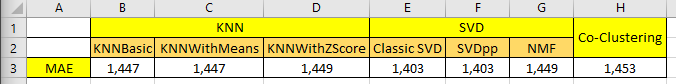

In [ ]:
params = {
    'n_factors': [25],
    'n_epochs': [10],
    'lr_all': [0.005],
    'reg_all': [0.002],
}

grid_search = GridSearchCV(SVDpp, param_grid=params, measures=['mae'])
grid_search.fit(train_data)

clear_output()

In [ ]:
best_model = grid_search.best_estimator['mae']

In [ ]:
# Добавим в датасет нового пользователя со случайными рейтингами трех случайных книг
new_user_id = len(ratings)

random_books_idxs = ratings.sample(n=3)['ISBN'].tolist()
random_books_names = books[books['ISBN'].apply(lambda x: x in random_books_idxs)]['Book-Title'].values

new_user_ratings = [
    (new_user_id, random_books_idxs[0], random.randint(1, 10)),
    (new_user_id, random_books_idxs[1], random.randint(1, 10)),
    (new_user_id, random_books_idxs[2], random.randint(1, 10)),
]

for book_name, rating in zip(random_books_names, [i[2] for i in new_user_ratings]):
    print(book_name, rating)

Hockey for Dummies 10
Moody in Winter 3
Reader's Greek-English Lexicon of the New Testament, A 1


In [ ]:
# Добавляем информацию о новом пользователе в датасет, заносим данные в модель
new_user_ratings_df = pd.DataFrame(new_user_ratings, columns=['User-ID', 'ISBN', 'Book-Rating'])

updated_ratings = pd.concat([ratings, new_user_ratings_df], ignore_index=True)

updated_data = Dataset.load_from_df(updated_ratings, reader)

updated_trainset = updated_data.build_full_trainset()

best_model.fit(updated_trainset)

In [ ]:
# Получаем все записи из датасета рейтингов, кроме записей самого пользователя
rated_items = set(updated_ratings[updated_ratings['User-ID'] == new_user_id]['ISBN'])
unrated_items = set(updated_ratings[updated_ratings['ISBN'].apply(lambda x: x not in rated_items)]['ISBN'].tolist())

# Предсказываем рейтинг для этих записей
predictions = []
for item_id in unrated_items:
    prediction = best_model.predict(new_user_id, item_id)

    predictions.append((item_id, prediction.est))

# Отсортируем предсказания по рейтингу в убывающем порядке
predictions_sorted = sorted(predictions, key=lambda x: x[1], reverse=True)

# Получаем топ n рекомендаций
top_n = 5
top_recommendations = [(books[books['ISBN'] == x[0]]['Book-Title'].values[0], round(x[1])) for x in predictions_sorted[:top_n]]

for book_name, rating in top_recommendations:
    print(book_name, rating)

Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)) 8
The Fellowship of the Ring (The Lord of the Rings, Part 1) 8
The Mists of Avalon 8
Harry Potter and the Goblet of Fire (Book 4) 8
The Five People You Meet in Heaven 8


#### Реализация conten-based фильтрации

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
# Строим эмбеддинги текстовых характеристик книг
title_embeddings = model.encode(books['Book-Title'].str.lower().tolist())
author_embeddings = model.encode(books['Book-Author'].str.lower().tolist())
publisher_embeddings = model.encode(books['Publisher'].str.lower().tolist())

In [ ]:
# Масштабируем числовую характеристику книг
scaler = MinMaxScaler()

books[['Year-Of-Publication-Normalized']] = scaler.fit_transform(books[['Year-Of-Publication']])

In [ ]:
# Для каждой книги формируем объединенный вектор характеристик
combined_features = np.hstack((title_embeddings, author_embeddings, books[['Year-Of-Publication-Normalized']], publisher_embeddings))

In [ ]:
# Нормализация векторов
norms = np.linalg.norm(combined_features, axis=1)

norms[norms == 0] = 1e-10

normalized_features = combined_features / norms[:, np.newaxis]

In [ ]:
# Для эффективной работы с векторами используем faiss
features_float32 = normalized_features.astype('float32')

faiss_index = faiss.IndexFlatIP(features_float32.shape[1])
faiss_index.add(features_float32)

In [ ]:
# Функция для поиска n похожих товаров для заданных
def get_recommendations(user_liked_books, n=5):
    indices = pd.Series(books.index, index=books['Book-Title']).drop_duplicates()
    liked_indices = [indices[title] for title in user_liked_books]

    liked_vectors = combined_features[liked_indices]

    # Находим усредненный вектор между заданными книгами
    user_vector = np.mean(liked_vectors, axis=0)

    # Нормализация усредненного вектора
    user_norm = np.linalg.norm(user_vector)
    user_vector_normalized = user_vector / user_norm

    user_vector_faiss = user_vector_normalized.reshape(1, -1).astype('float32')

    # При помощи faiss находим ближайшие книги в векторном хранилище
    D, I = faiss_index.search(user_vector_faiss, n + len(liked_indices))

    recommended_indices = [idx for idx in I[0] if idx not in liked_indices]

    recommended_books = books.iloc[recommended_indices[:n]]['Book-Title'].tolist()

    return recommended_books

In [ ]:
random_books_names_filtered = [x[0] for x in zip(random_books_names, [i[2] for i in new_user_ratings]) if x[1] >= 7]

similar_books = get_recommendations(random_books_names_filtered, n=5)

for random_book in random_books_names_filtered:
    print(random_book)

print('-'*10)

for similar_book in similar_books:
    print(similar_book)

Hockey for Dummies
----------
Chess for Dummies
Magic for Dummies
Investing for Dummies, Second Edition
Small Business Kit for Dummies
Mutual Fund$ For Dummie$Â¨


In [ ]:
random_books_names_filtered = ['Python Web Programming']

similar_books = get_recommendations(random_books_names_filtered, n=5)

for random_book in random_books_names_filtered:
    print(random_book)

print('-'*10)

for similar_book in similar_books:
    print(similar_book)

Python Web Programming
----------
ASP.NET Unleashed, Second Edition
Sams Teach Yourself Microsoft FrontPage 2000 in 10 Minutes
How to maintain and service your small computer
Coral Reef (Eye to Eye)
TNT : Telzey &amp; Trigger


In [ ]:
random_books_names_filtered = ["Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"]

similar_books = get_recommendations(random_books_names_filtered, n=5)

for random_book in random_books_names_filtered:
    print(random_book)

print('-'*10)

for similar_book in similar_books:
    print(similar_book)

Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))
----------
Harry Potter and the Sorcerer's Stone (Book 1)
Harry Potter and the Sorcerer's Stone (Book 1)
Harry Potter and the Goblet of Fire (Book 4)
Harry Potter and the Prisoner of Azkaban (Book 3)
Harry Potter and the Prisoner of Azkaban (Book 3)
